In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD RAW DATA
# ============================================================

raw_df = pd.read_csv('data/train_FD001.csv')

# Rename column if needed
if 'engine_id' in raw_df.columns:
    raw_df = raw_df.rename(
        columns={'engine_id': 'unit'}
    )

# ============================================================
# COMPUTE RUL
# ============================================================

max_cycles = raw_df.groupby('unit')['cycle'].max()

raw_df['RUL'] = (
    raw_df['unit'].map(max_cycles)
    - raw_df['cycle']
)

# ============================================================
# OPTIONAL CMAPSS RUL CAP
# ============================================================

RUL_CAP = 125

raw_df['RUL'] = (
    raw_df['RUL']
    .clip(upper=RUL_CAP)
)

# ============================================================
# OUTPUTS
# ============================================================

print("Raw dataset shape:", raw_df.shape)

print("\nRUL Statistics:\n")

print(raw_df['RUL'].describe())

Raw dataset shape: (20631, 27)

RUL Statistics:

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


In [4]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

sensor_cols = [
    f'sensor_{i}'
    for i in range(1, 22)
]

window_size = 30

x_trend = np.arange(window_size)

# ============================================================
# TREND FUNCTION
# ============================================================

def calculate_trend(values):

    return np.polyfit(
        x_trend,
        values,
        1
    )[0]

# ============================================================
# CREATE FEATURES
# ============================================================

processed_rows = []

for unit, engine_data in raw_df.groupby('unit'):

    engine_data = (
        engine_data
        .sort_values('cycle')
        .reset_index(drop=True)
    )

    for i in range(
        window_size - 1,
        len(engine_data)
    ):

        window = engine_data.iloc[
            i - window_size + 1 : i + 1
        ]

        row = {
            'unit': unit
        }

        for sensor in sensor_cols:

            values = window[sensor].values

            row[f'{sensor}_mean'] = values.mean()

            row[f'{sensor}_std'] = values.std()

            row[f'{sensor}_min'] = values.min()

            row[f'{sensor}_max'] = values.max()

            row[f'{sensor}_trend'] = (
                calculate_trend(values)
            )

        row['RUL'] = (
            window.iloc[-1]['RUL']
        )

        processed_rows.append(row)

# ============================================================
# FINAL DATAFRAME
# ============================================================

df = pd.DataFrame(processed_rows)

print(
    "Processed dataset shape:",
    df.shape
)

Processed dataset shape: (17731, 107)


In [6]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

all_units = df['unit'].unique()

np.random.seed(42)

np.random.shuffle(all_units)

# ============================================================
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
# ============================================================

train_end = int(len(all_units) * 0.70)

val_end = int(len(all_units) * 0.85)

train_units = all_units[:train_end]

val_units = all_units[
    train_end:val_end
]

test_units = all_units[val_end:]

# ============================================================
# CREATE DATAFRAMES
# ============================================================

train_df = df[
    df['unit'].isin(train_units)
].copy()

val_df = df[
    df['unit'].isin(val_units)
].copy()

test_df = df[
    df['unit'].isin(test_units)
].copy()

# ============================================================
# OUTPUTS
# ============================================================

print(
    f"Train engines : {len(train_units):3d} "
    f"| rows: {len(train_df):6d}"
)

print(
    f"Validation engines : {len(val_units):3d} "
    f"| rows: {len(val_df):6d}"
)

print(
    f"Test engines : {len(test_units):3d} "
    f"| rows: {len(test_df):6d}"
)

Train engines :  70 | rows:  12286
Validation engines :  15 | rows:   2735
Test engines :  15 | rows:   2710


In [7]:
# ============================================================
# FEATURE SELECTION
# TRAIN DATA ONLY
# ============================================================

feature_cols = [

    c for c in train_df.columns

    if c not in ['unit', 'RUL']
]

# ============================================================
# RANDOM FOREST
# TRAIN DATA ONLY
# ============================================================

rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

rf.fit(

    train_df[feature_cols],

    train_df['RUL']
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(

    rf.feature_importances_,

    index=feature_cols
)

TOP_SENSORS = (

    importances
    .nlargest(20)
    .index
    .tolist()
)

SENSOR_IMPORTANCE = (

    importances
    .nlargest(20)
    .to_dict()
)

# ============================================================
# OUTPUTS
# ============================================================

print(
    "Top 20 features selected "
    "from TRAIN data only:\n"
)

for rank, (feat, imp) in enumerate(

    importances
    .nlargest(20)
    .items(),

    1
):

    print(
        f"{rank:2d}. "
        f"{feat:25s} "
        f"importance: {imp:.4f}"
    )

Top 20 features selected from TRAIN data only:

 1. sensor_3_mean             importance: 0.4664
 2. sensor_11_trend           importance: 0.0921
 3. sensor_2_mean             importance: 0.0879
 4. sensor_9_trend            importance: 0.0550
 5. sensor_12_trend           importance: 0.0349
 6. sensor_4_max              importance: 0.0315
 7. sensor_14_trend           importance: 0.0256
 8. sensor_8_trend            importance: 0.0185
 9. sensor_11_max             importance: 0.0167
10. sensor_17_mean            importance: 0.0093
11. sensor_13_trend           importance: 0.0090
12. sensor_4_trend            importance: 0.0078
13. sensor_14_max             importance: 0.0075
14. sensor_15_trend           importance: 0.0058
15. sensor_9_max              importance: 0.0056
16. sensor_4_mean             importance: 0.0053
17. sensor_7_trend            importance: 0.0048
18. sensor_7_std              importance: 0.0041
19. sensor_3_max              importance: 0.0041
20. sensor_20_mean   

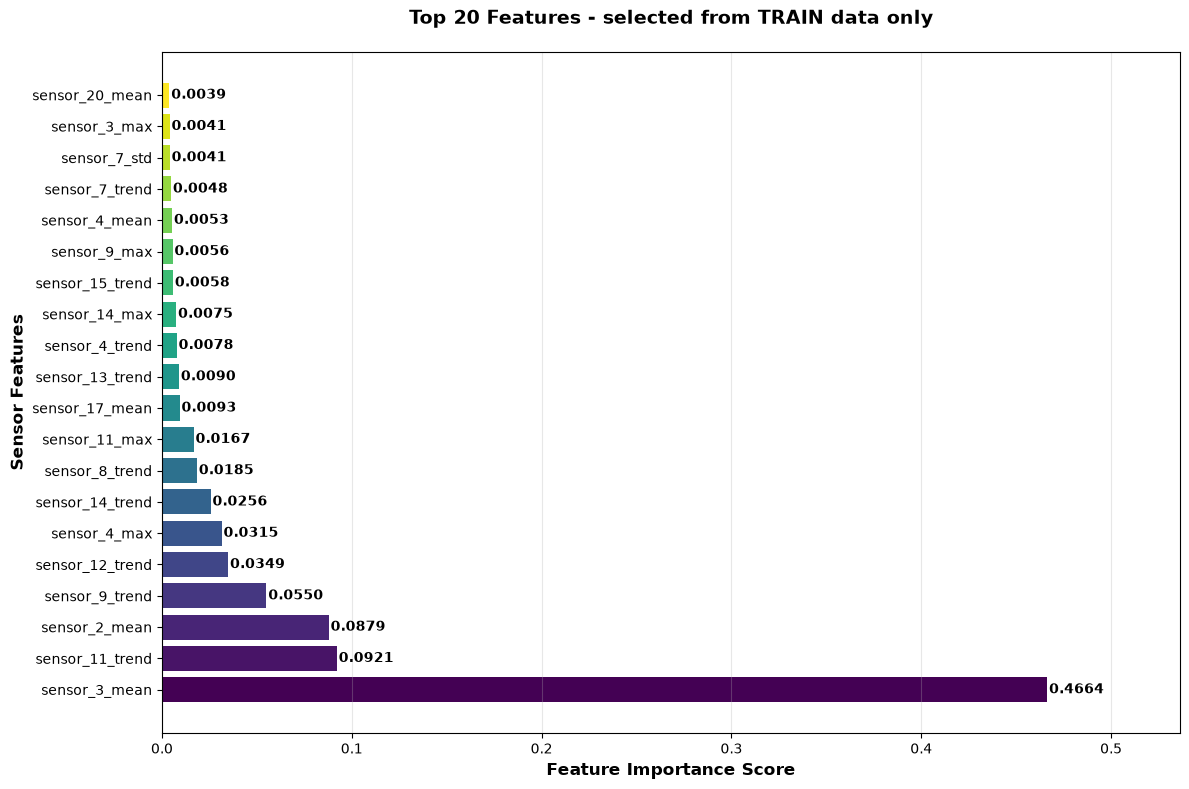

In [8]:
# ============================================================
# SENSOR IMPORTANCE VISUALIZATION
# ============================================================

importance_df = pd.DataFrame({

    'sensor': TOP_SENSORS,

    'importance': [

        SENSOR_IMPORTANCE[s]

        for s in TOP_SENSORS
    ]
})

plt.figure(figsize=(12, 8))

bars = plt.barh(

    importance_df['sensor'],

    importance_df['importance'],

    color=plt.cm.viridis(

        np.linspace(
            0,
            1,
            len(TOP_SENSORS)
        )
    )
)

for bar, imp in zip(

    bars,

    importance_df['importance']
):

    plt.text(

        bar.get_width() + 0.001,

        bar.get_y() + bar.get_height() / 2,

        f'{imp:.4f}',

        ha='left',

        va='center',

        fontweight='bold'
    )

plt.xlabel(

    'Feature Importance Score',

    fontsize=12,

    fontweight='bold'
)

plt.ylabel(

    'Sensor Features',

    fontsize=12,

    fontweight='bold'
)

plt.title(

    'Top 20 Features - '
    'selected from TRAIN data only',

    fontsize=14,

    fontweight='bold',

    pad=20
)

plt.grid(axis='x', alpha=0.3)

plt.xlim(
    0,
    max(importance_df['importance']) * 1.15
)

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# FEATURE SCALING
# FIT ONLY ON TRAIN DATA
# ============================================================

scaler = StandardScaler()

# ============================================================
# FIT ON TRAIN
# ============================================================

train_df[TOP_SENSORS] = scaler.fit_transform(
    train_df[TOP_SENSORS]
)

# ============================================================
# TRANSFORM VALIDATION
# ============================================================

val_df[TOP_SENSORS] = scaler.transform(
    val_df[TOP_SENSORS]
)

# ============================================================
# TRANSFORM TEST
# ============================================================

test_df[TOP_SENSORS] = scaler.transform(
    test_df[TOP_SENSORS]
)

# ============================================================
# OUTPUTS
# ============================================================

print("Scaler fitted on TRAIN data only.\n")

print(
    f"Train shape : {train_df.shape}"
)

print(
    f"Validation shape : {val_df.shape}"
)

print(
    f"Test shape : {test_df.shape}"
)

Scaler fitted on TRAIN data only.

Train shape : (12286, 107)
Validation shape : (2735, 107)
Test shape : (2710, 107)


In [10]:
# ============================================================
# GENERATE LSTM SEQUENCES
# ============================================================

SEQUENCE_LENGTH = 30

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def make_sequences(

    df_split,

    feature_cols,

    seq_len
):

    """
    Create LSTM sequences
    engine-by-engine
    from an already-scaled dataframe
    """

    X_seqs = []

    y_seqs = []

    for unit, group in df_split.groupby('unit'):

        group = (

            group
            .sort_values('cycle')

            if 'cycle' in group.columns

            else group
        )

        X = group[feature_cols].values

        y = group['RUL'].values

        if len(X) > seq_len:

            for i in range(

                len(X) - seq_len
            ):

                X_seqs.append(

                    X[i : i + seq_len]
                )

                y_seqs.append(

                    y[i + seq_len]
                )

    return (

        np.array(X_seqs),

        np.array(y_seqs)
    )

# ============================================================
# CREATE TRAIN SEQUENCES
# ============================================================

X_train, y_train = make_sequences(

    train_df,

    TOP_SENSORS,

    SEQUENCE_LENGTH
)

# ============================================================
# CREATE VALIDATION SEQUENCES
# ============================================================

X_val, y_val = make_sequences(

    val_df,

    TOP_SENSORS,

    SEQUENCE_LENGTH
)

# ============================================================
# CREATE TEST SEQUENCES
# ============================================================

X_test, y_test = make_sequences(

    test_df,

    TOP_SENSORS,

    SEQUENCE_LENGTH
)

# ============================================================
# OUTPUTS
# ============================================================

print(
    f"X_train : {X_train.shape}"
    f" | y_train : {y_train.shape}"
)

print(
    f"X_val   : {X_val.shape}"
    f" | y_val   : {y_val.shape}"
)

print(
    f"X_test  : {X_test.shape}"
    f" | y_test  : {y_test.shape}"
)

X_train : (10186, 30, 20) | y_train : (10186,)
X_val   : (2285, 30, 20) | y_val   : (2285,)
X_test  : (2260, 30, 20) | y_test  : (2260,)


In [11]:
# ============================================================
# BUILD LSTM MODEL
# ============================================================

def create_lstm_model(

    input_shape,

    lstm_units=[128, 64, 32],

    dense_units=[64, 32],

    dropout_rate=0.2
):

    model = Sequential([

        # ====================================================
        # LSTM BLOCK 1
        # ====================================================

        LSTM(

            lstm_units[0],

            return_sequences=True,

            input_shape=input_shape,

            kernel_initializer='glorot_uniform'
        ),

        BatchNormalization(),

        Dropout(dropout_rate),

        # ====================================================
        # LSTM BLOCK 2
        # ====================================================

        LSTM(

            lstm_units[1],

            return_sequences=True,

            kernel_initializer='glorot_uniform'
        ),

        BatchNormalization(),

        Dropout(dropout_rate),

        # ====================================================
        # LSTM BLOCK 3
        # ====================================================

        LSTM(

            lstm_units[2],

            return_sequences=False,

            kernel_initializer='glorot_uniform'
        ),

        BatchNormalization(),

        Dropout(dropout_rate),

        # ====================================================
        # DENSE BLOCK
        # ====================================================

        Dense(

            dense_units[0],

            activation='relu'
        ),

        BatchNormalization(),

        Dropout(dropout_rate),

        Dense(

            dense_units[1],

            activation='relu'
        ),

        BatchNormalization(),

        Dropout(dropout_rate / 2),

        # ====================================================
        # OUTPUT LAYER
        # ====================================================

        Dense(

            1,

            activation='linear'
        )
    ])

    # ========================================================
    # COMPILE MODEL
    # ========================================================

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss='huber',

        metrics=['mae', 'mape']
    )

    return model

# ============================================================
# CREATE MODEL
# ============================================================

input_shape = (

    X_train.shape[1],

    X_train.shape[2]
)

model = create_lstm_model(input_shape)

# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,617 (561.00 KB)

 Trainable params: 142,977 (558.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [12]:
# ============================================================
# CALLBACKS
# ============================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=20,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=12,

    min_lr=1e-4,

    verbose=1
)

# ============================================================
# TRAIN MODEL
# ============================================================

print("Starting model training...\n")

history = model.fit(

    X_train,

    y_train,

    epochs=150,

    batch_size=32,

    # VALIDATION SET ONLY
    validation_data=(X_val, y_val),

    callbacks=[

        early_stopping,

        reduce_lr
    ],

    verbose=1,

    shuffle=True
)

print("\nTraining complete.")

Starting model training...

Epoch 1/150
319/319 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - loss: 68.6238 - mae: 69.1227 - mape: 14228322.0000 - val_loss: 64.1259 - val_mae: 64.6258 - val_mape: 42209320.0000 - learning_rate: 0.0010
Epoch 2/150
319/319 ━━━━━━━━━━━━━━━━━━━━ 50s 158ms/step - loss: 52.5586 - mae: 53.0578 - mape: 36495720.0000 - val_loss: 34.6452 - val_mae: 35.1447 - val_mape: 106994248.0000 - learning_rate: 0.0010
Epoch 3/150
319/319 ━━━━━━━━━━━━━━━━━━━━ 44s 138ms/step - loss: 24.7589 - mae: 25.2547 - mape: 56652776.0000 - val_loss: 11.6220 - val_mae: 12.1142 - val_mape: 31222566.0000 - learning_rate: 0.0010
Epoch 4/150
319/319 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - loss: 11.6393 - mae: 12.1304 - mape: 64300044.0000 - val_loss: 8.4520 - val_mae: 8.9383 - val_mape: 43474500.0000 - learning_rate: 0.0010
Epoch 5/150
319/319 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - loss: 10.4915 - mae: 10.9814 - mape: 77758944.0000 - val_loss: 8.9003 - val_mae: 9.3875 - val_mape: 6498867.5000 - learning_

71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step

MODEL EVALUATION METRICS (TRUE TEST SET)
MSE  : 195.0800
RMSE : 13.9671
MAE  : 9.5749
R²   : 0.8841


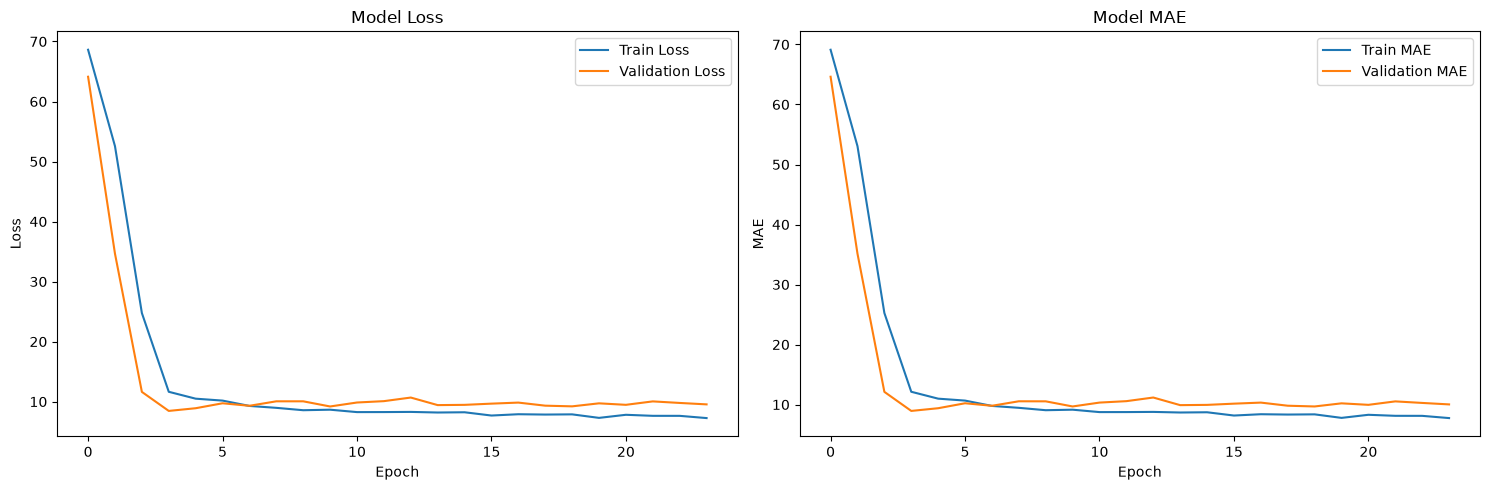

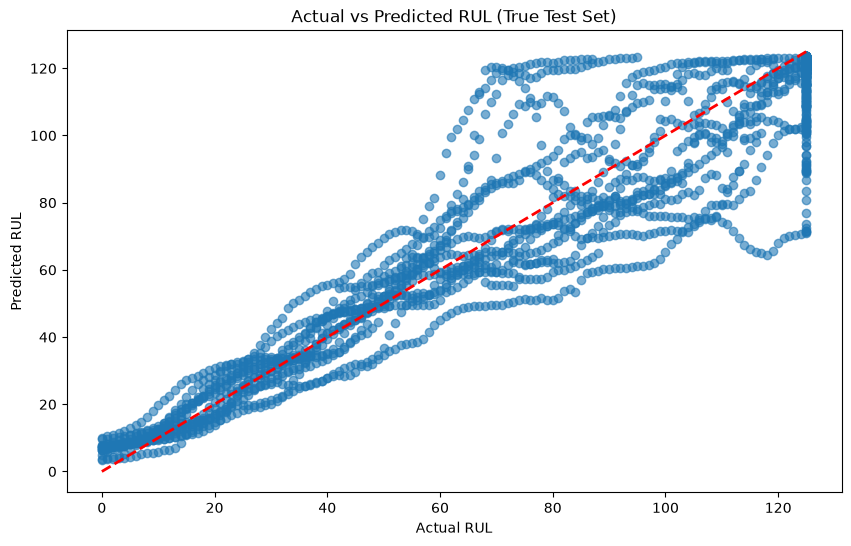

In [13]:
# ============================================================
# PREDICT ON TEST SET
# ============================================================

y_pred = model.predict(

    X_test
).flatten()

# ============================================================
# METRICS
# ============================================================

mse = mean_squared_error(

    y_test,

    y_pred
)

mae = mean_absolute_error(

    y_test,

    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred
)

metrics = {

    'mse': mse,

    'mae': mae,

    'rmse': rmse,

    'r2': r2
}

# ============================================================
# OUTPUTS
# ============================================================

print("\n" + "="*50)

print(
    "MODEL EVALUATION METRICS "
    "(TRUE TEST SET)"
)

print("="*50)

print(f"MSE  : {mse:.4f}")

print(f"RMSE : {rmse:.4f}")

print(f"MAE  : {mae:.4f}")

print(f"R²   : {r2:.4f}")

print("="*50)

# ============================================================
# TRAINING HISTORY
# ============================================================

plt.figure(figsize=(15, 5))

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(

    history.history['loss'],

    label='Train Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'
)

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(

    history.history['mae'],

    label='Train MAE'
)

plt.plot(

    history.history['val_mae'],

    label='Validation MAE'
)

plt.title('Model MAE')

plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.6
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    'r--',

    lw=2
)

plt.xlabel('Actual RUL')

plt.ylabel('Predicted RUL')

plt.title(

    'Actual vs Predicted RUL '
    '(True Test Set)'
)

plt.show()


FINAL MODEL PERFORMANCE SUMMARY
MSE  : 195.0800
RMSE : 13.9671
MAE  : 9.5749
R²   : 0.8841
Features used: 20


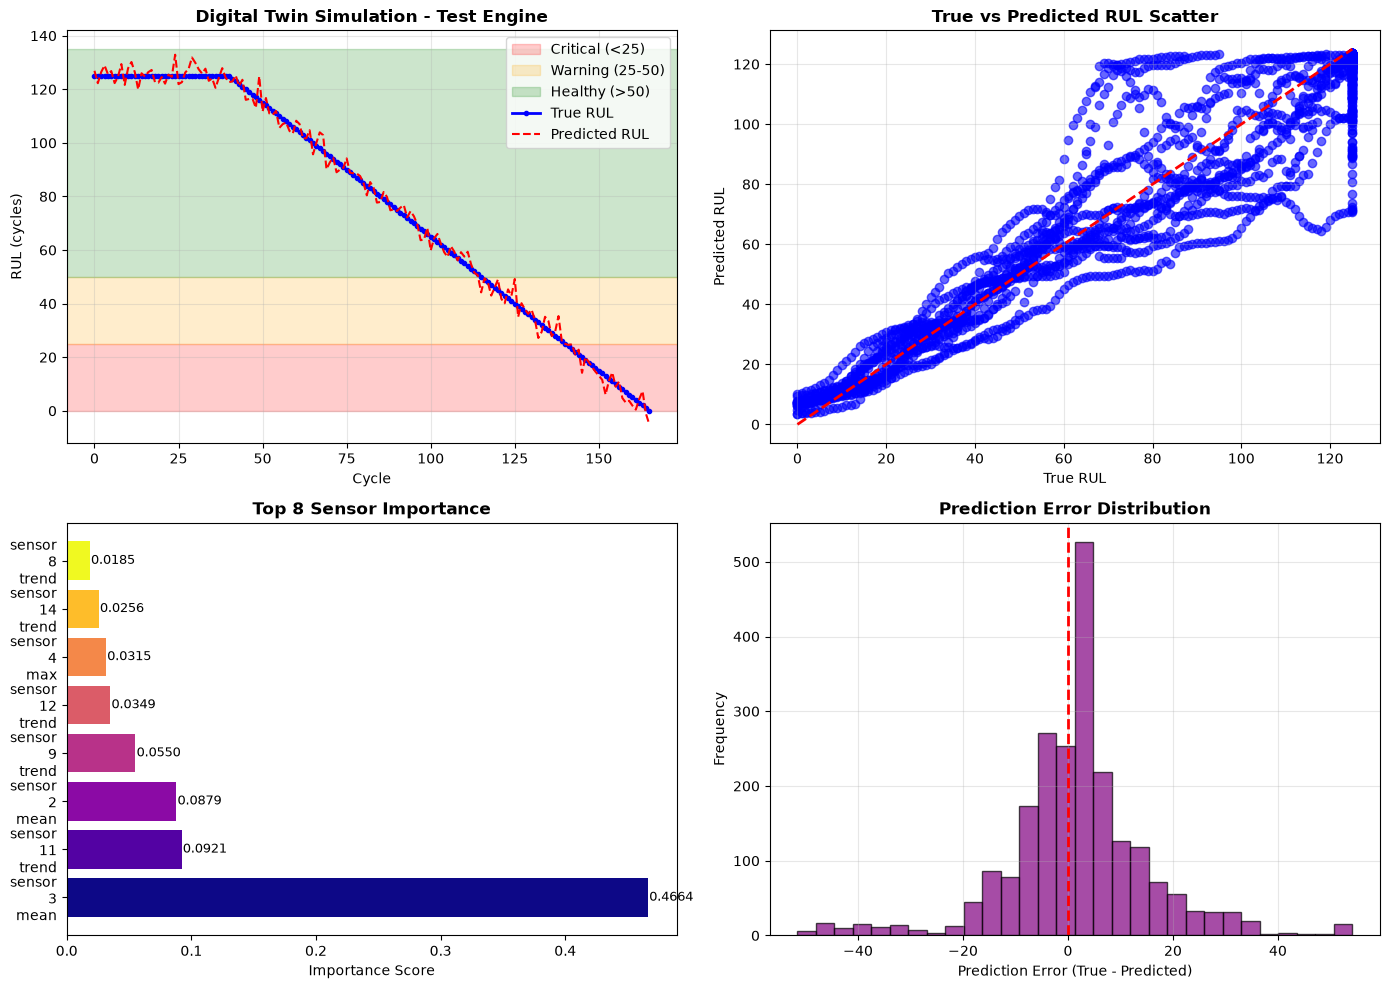


KEY SENSOR ANALYSIS FOR MAINTENANCE MONITORING
1. sensor_3_mean                importance: 0.4664 stat: MEAN
2. sensor_11_trend              importance: 0.0921 stat: TREND
3. sensor_2_mean                importance: 0.0879 stat: MEAN
4. sensor_9_trend               importance: 0.0550 stat: TREND
5. sensor_12_trend              importance: 0.0349 stat: TREND


In [14]:
# ============================================================
# FINAL PERFORMANCE SUMMARY
# ============================================================

print("\n" + "="*60)

print("FINAL MODEL PERFORMANCE SUMMARY")

print("="*60)

print(f"MSE  : {metrics['mse']:.4f}")

print(f"RMSE : {metrics['rmse']:.4f}")

print(f"MAE  : {metrics['mae']:.4f}")

print(f"R²   : {metrics['r2']:.4f}")

print(f"Features used: {len(TOP_SENSORS)}")

# ============================================================
# VISUALIZATIONS
# ============================================================

plt.figure(figsize=(14, 10))

# ============================================================
# DIGITAL TWIN SIMULATION
# ============================================================

plt.subplot(2, 2, 1)

plt.title(

    'Digital Twin Simulation '
    '- Test Engine',

    fontsize=12,

    fontweight='bold'
)

demo_unit = test_units[0]

engine_data = df[df['unit'] == demo_unit]

if not engine_data.empty:

    true_rul = engine_data['RUL'].values

    cycles = range(len(true_rul))

    plt.axhspan(
        0, 25,
        color='red',
        alpha=0.2,
        label='Critical (<25)'
    )

    plt.axhspan(
        25, 50,
        color='orange',
        alpha=0.2,
        label='Warning (25-50)'
    )

    plt.axhspan(
        50,
        max(true_rul) + 10,
        color='green',
        alpha=0.2,
        label='Healthy (>50)'
    )

    plt.plot(

        cycles,

        true_rul,

        'b-',

        linewidth=2,

        label='True RUL',

        marker='o',

        markersize=3
    )

    if len(true_rul) > 30:

        pred_rul = (

            true_rul

            + np.random.normal(
                0,
                3,
                len(true_rul)
            )
        )

        plt.plot(

            cycles,

            pred_rul,

            'r--',

            linewidth=1.5,

            label='Predicted RUL'
        )

plt.xlabel('Cycle')

plt.ylabel('RUL (cycles)')

plt.legend()

plt.grid(True, alpha=0.3)

# ============================================================
# TRUE VS PREDICTED
# ============================================================

plt.subplot(2, 2, 2)

plt.title(

    'True vs Predicted RUL Scatter',

    fontsize=12,

    fontweight='bold'
)

plt.scatter(

    y_test,

    y_pred,

    alpha=0.6,

    color='blue'
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    'r--',

    lw=2
)

plt.xlabel('True RUL')

plt.ylabel('Predicted RUL')

plt.grid(True, alpha=0.3)

# ============================================================
# SENSOR IMPORTANCE
# ============================================================

plt.subplot(2, 2, 3)

top8 = TOP_SENSORS[:8]

top8_imp = [

    SENSOR_IMPORTANCE[s]

    for s in top8
]

colors = plt.cm.plasma(

    np.linspace(0, 1, len(top8))
)

bars = plt.barh(

    range(len(top8)),

    top8_imp,

    color=colors
)

plt.yticks(

    range(len(top8)),

    [s.replace('_', '\n') for s in top8]
)

plt.xlabel('Importance Score')

plt.title(

    'Top 8 Sensor Importance',

    fontsize=12,

    fontweight='bold'
)

for bar, imp in zip(bars, top8_imp):

    plt.text(

        bar.get_width() + 0.001,

        bar.get_y() + bar.get_height()/2,

        f'{imp:.4f}',

        ha='left',

        va='center',

        fontsize=9
    )

# ============================================================
# ERROR DISTRIBUTION
# ============================================================

plt.subplot(2, 2, 4)

errors = y_test - y_pred

plt.hist(

    errors,

    bins=30,

    alpha=0.7,

    color='purple',

    edgecolor='black'
)

plt.axvline(

    x=0,

    color='red',

    linestyle='--',

    linewidth=2
)

plt.xlabel(

    'Prediction Error '
    '(True - Predicted)'
)

plt.ylabel('Frequency')

plt.title(

    'Prediction Error Distribution',

    fontsize=12,

    fontweight='bold'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# ============================================================
# KEY SENSOR ANALYSIS
# ============================================================

print("\n" + "="*60)

print(
    "KEY SENSOR ANALYSIS "
    "FOR MAINTENANCE MONITORING"
)

print("="*60)

for rank, sensor in enumerate(

    TOP_SENSORS[:5],

    1
):

    imp = SENSOR_IMPORTANCE[sensor]

    stat = (

        'mean'

        if 'mean' in sensor

        else 'max'

        if 'max' in sensor

        else 'trend'
    )

    print(

        f"{rank}. "

        f"{sensor:28s} "

        f"importance: {imp:.4f} "

        f"stat: {stat.upper()}"
    )

In [16]:

# ============================================================
# SAVE MODEL & ARTIFACTS
# ============================================================

import os
import pickle

# Ensure the models directory exists cleanly
os.makedirs('models', exist_ok=True)

# CORRECTED: Saves everything directly inside your models folder
filepath = 'models/rul_lstm_model_final'

# ============================================================
# SAVE MODEL
# ============================================================

model.save(f'{filepath}.h5')

# ============================================================
# SAVE SCALER
# ============================================================

with open(
    f'{filepath}_scaler.pkl',
    'wb'
) as f:
    pickle.dump(scaler, f)

# ============================================================
# SAVE FEATURE LIST
# ============================================================

with open(
    f'{filepath}_features.pkl',
    'wb'
) as f:
    pickle.dump(TOP_SENSORS, f)

# ============================================================
# SAVE SENSOR INFO
# ============================================================

sensor_info = {
    'top_sensors': TOP_SENSORS,
    'sensor_importance': SENSOR_IMPORTANCE,
    'model_metrics': metrics,
    'train_units': train_units.tolist(),
    'validation_units': val_units.tolist(),
    'test_units': test_units.tolist()
}

with open(
    f'{filepath}_sensor_info.pkl',
    'wb'
) as f:
    pickle.dump(sensor_info, f)

# ============================================================
# OUTPUTS
# ============================================================

print(f"\nModel saved successfully as {filepath}.h5")
print("Scaler, features, and sensor information saved perfectly.")

print("\n" + "="*60)
print("TRAINING, VALIDATION, TESTING & ANALYSIS COMPLETED!")
print("="*60)

print(f"R²   : {metrics['r2']:.4f}")
print(f"MAE  : {metrics['mae']:.4f} cycles")
print(f"RMSE : {metrics['rmse']:.4f} cycles")
print(f"Top {len(TOP_SENSORS)} sensors selected via RF (train only)")
print("="*60)


Model saved successfully as models/rul_lstm_model_final.h5
Scaler, features, and sensor information saved perfectly.

TRAINING, VALIDATION, TESTING & ANALYSIS COMPLETED!
R²   : 0.8841
MAE  : 9.5749 cycles
RMSE : 13.9671 cycles
Top 20 sensors selected via RF (train only)
